# Audio Classifier — CNN Baseline + BirdNET Pretrained

Two approaches to audio bird species classification on our Xeno-canto SD subset:

1. **CNN from scratch** — lightweight CNN trained on mel spectrograms using `_build_audio_cnn`
   from `src/audio/classify.py`. Honest attempt at training on limited data.
2. **BirdNET pretrained** — BirdNET global model via birdnetlib, no training required.
   Matches detections to our 18 SD species by scientific name from species.yaml.

**Targets to beat (Phase 3 KNN baseline):**
- Test accuracy: 0.302
- Macro F1: 0.191
- Weighted F1: 0.293

**Outputs:**
- `models/audio/finetuned_sdbirds.pt` — CNN checkpoint
- `notebooks/results/audio_cnn_confusion_matrix.png`
- `notebooks/results/audio_cnn_per_class_f1.png`
- `notebooks/results/audio_cnn_loss_curve.png`
- `notebooks/results/audio_birdnet_confusion_matrix.png`
- `notebooks/results/audio_birdnet_per_class_f1.png`
- `notebooks/results/experiments.csv` — new rows appended (deduplication guard active)

## 0. Setup and imports

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.utils.data import DataLoader, Dataset

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path(".").resolve().parent))

from src.audio.classify import _build_audio_cnn
from src.audio.preprocess import preprocess_file as audio_preprocess_file

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.3.0+cpu


## 1. Load label map and splits

In [2]:
REPO_ROOT   = Path(".").resolve().parent
SPLITS_DIR  = REPO_ROOT / "data" / "splits"
MODELS_DIR  = REPO_ROOT / "models" / "audio"
RESULTS_DIR = REPO_ROOT / "notebooks" / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

experiments_path = RESULTS_DIR / "experiments.csv"

# Load audio label map and re-index to 0..n_classes-1.
# audio_label_map.json uses shared indices (skips AMCR index 0),
# so we remap to dense 0-based indices for CNN training.
with open(REPO_ROOT / "models" / "audio_label_map.json") as f:
    raw = json.load(f)

sorted_codes = [v for k, v in sorted(raw.items(), key=lambda x: int(x[0]))]
label_map    = {i: code for i, code in enumerate(sorted_codes)}  # 0-based
code_to_idx  = {code: i for i, code in label_map.items()}
n_classes    = len(label_map)

print(f"Audio label map: {n_classes} species")
print(f"Species: {list(label_map.values())}")

audio_train = pd.read_csv(SPLITS_DIR / "audio_train.csv")
audio_val   = pd.read_csv(SPLITS_DIR / "audio_val.csv")
audio_test  = pd.read_csv(SPLITS_DIR / "audio_test.csv")

print(f"\nSplit sizes | train={len(audio_train)} val={len(audio_val)} test={len(audio_test)}")

Audio label map: 18 species
Species: ['AMRO', 'ANHU', 'BLPH', 'DOWO', 'EUST', 'HOFI', 'HOORI', 'HOSP', 'LEGO', 'MOCH', 'MODO', 'OCWA', 'SOSP', 'SPTO', 'WBNU', 'WCSP', 'WREN', 'YRUM']

Split sizes | train=251 val=83 test=86


## 2. Dataset class

In [3]:
class SpectrogramDataset(Dataset):
    """
    Loads mel spectrograms from WAV/MP3 files on the fly using src.audio.preprocess.
    Pads or truncates to TARGET_FRAMES for batch consistency.
    """

    TARGET_FRAMES = 282  # ~3 seconds at 48kHz with default hop_length

    def __init__(self, df: pd.DataFrame, code_to_idx: dict):
        self.df = df.reset_index(drop=True)
        self.code_to_idx = code_to_idx

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row          = self.df.iloc[idx]
        file_path    = Path(row["file_path"])
        species_code = row["species_code"]

        try:
            spec = audio_preprocess_file(str(file_path))
        except Exception as e:
            print(f"Warning: failed to load {file_path}: {e} — using zeros")
            spec = np.zeros((128, self.TARGET_FRAMES), dtype=np.float32)

        t = spec.shape[1]
        if t < self.TARGET_FRAMES:
            spec = np.pad(spec, ((0, 0), (0, self.TARGET_FRAMES - t)))
        else:
            spec = spec[:, : self.TARGET_FRAMES]

        tensor = torch.from_numpy(spec.astype(np.float32)).unsqueeze(0)
        label  = self.code_to_idx[species_code]
        return tensor, label

In [4]:
train_ds = SpectrogramDataset(audio_train, code_to_idx)
val_ds   = SpectrogramDataset(audio_val,   code_to_idx)
test_ds  = SpectrogramDataset(audio_test,  code_to_idx)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=0)

print(f"Batches | train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}")
x, y = next(iter(train_loader))
print(f"Batch shape: {x.shape}  Labels: {y.shape}")

Batches | train=16 val=6 test=6
Batch shape: torch.Size([16, 1, 128, 282])  Labels: torch.Size([16])


## 3. Model, optimizer, scheduler

In [5]:
model = _build_audio_cnn(n_classes=n_classes).to(DEVICE)

# Weighted CE loss to handle thin-data species (ANHU, BLPH etc.)
class_counts   = audio_train["species_code"].value_counts()
sorted_indices = sorted(label_map.keys())
weights = torch.tensor(
    [1.0 / class_counts.get(label_map[i], 1) for i in sorted_indices],
    dtype=torch.float32,
).to(DEVICE)
weights = weights / weights.sum() * n_classes

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 95,442


## 4. Training loop

In [6]:
EPOCHS = 30
CHECKPOINT_PATH = MODELS_DIR / "finetuned_sdbirds.pt"

if CHECKPOINT_PATH.exists():
    print(f"Checkpoint exists — skipping training.")
    train_losses, val_losses = [], []
else:
    train_losses, val_losses = [], []
    best_val_loss = float("inf")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch), y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(x_batch)
        train_loss = running_loss / len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(x_batch), y_batch).item() * len(x_batch)
        val_loss /= len(val_ds)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                    "n_classes": n_classes,
                    "label_map": label_map,
                },
                CHECKPOINT_PATH,
            )

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{EPOCHS} | train={train_loss:.4f} val={val_loss:.4f} | best={best_val_loss:.4f}")

    print(f"\nBest checkpoint saved -> {CHECKPOINT_PATH}")

Checkpoint exists — skipping training.


## 5. Loss curve

In [7]:
if train_losses:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, EPOCHS + 1), train_losses, label="Train loss")
    ax.plot(range(1, EPOCHS + 1), val_losses,   label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_title("Audio CNN — Training Loss Curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "audio_cnn_loss_curve.png", dpi=150)
    plt.show()
    print("Saved: audio_cnn_loss_curve.png")
else:
    checkpoint_data = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    print(f"Checkpoint from epoch {checkpoint_data['epoch']}, val_loss={checkpoint_data['val_loss']:.4f}")
    print("Loss curve already saved from previous run — skipping plot.")

Checkpoint from epoch 25, val_loss=2.8042
Loss curve already saved from previous run — skipping plot.


## 6. CNN — Evaluation on test set

In [8]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        preds = model(x_batch.to(DEVICE)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds     = np.array(all_preds)
all_labels    = np.array(all_labels)
species_names = [label_map[i] for i in range(n_classes)]

cnn_macro_f1    = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
cnn_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
cnn_accuracy    = (all_preds == all_labels).mean()

print(f"Test accuracy : {cnn_accuracy:.3f}  (baseline KNN: 0.302)")
print(f"Macro F1      : {cnn_macro_f1:.3f}  (baseline KNN: 0.191)  {'BEAT' if cnn_macro_f1 > 0.191 else 'below baseline'}")
print(f"Weighted F1   : {cnn_weighted_f1:.3f}  (baseline KNN: 0.293)")
print()
print(classification_report(all_labels, all_preds, target_names=species_names, zero_division=0))

Test accuracy : 0.116  (baseline KNN: 0.302)
Macro F1      : 0.089  (baseline KNN: 0.191)  below baseline
Weighted F1   : 0.093  (baseline KNN: 0.293)

              precision    recall  f1-score   support

        AMRO       0.00      0.00      0.00        10
        ANHU       0.00      0.00      0.00         2
        BLPH       0.00      0.00      0.00         1
        DOWO       0.12      1.00      0.22         1
        EUST       0.00      0.00      0.00         3
        HOFI       0.00      0.00      0.00        10
       HOORI       0.17      0.67      0.27         3
        HOSP       0.00      0.00      0.00         2
        LEGO       0.00      0.00      0.00         7
        MOCH       0.11      0.33      0.17         3
        MODO       0.05      1.00      0.10         1
        OCWA       0.00      0.00      0.00         2
        SOSP       0.00      0.00      0.00         7
        SPTO       0.33      0.33      0.33         6
        WBNU       1.00      0.14    

## 7. CNN — Confusion matrix

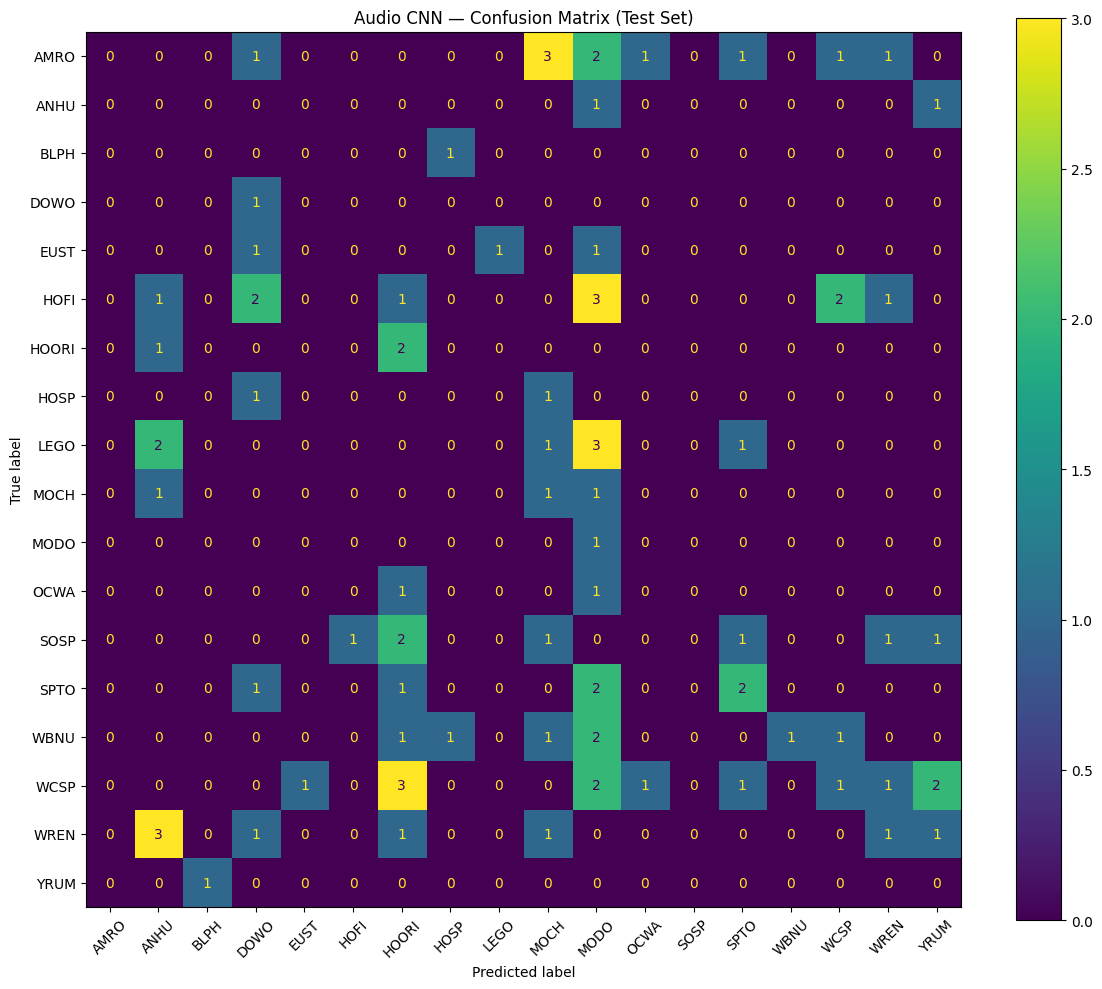

Saved: audio_cnn_confusion_matrix.png


In [9]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species_names)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title("Audio CNN — Confusion Matrix (Test Set)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "audio_cnn_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: audio_cnn_confusion_matrix.png")

## 8. CNN — Per-class F1

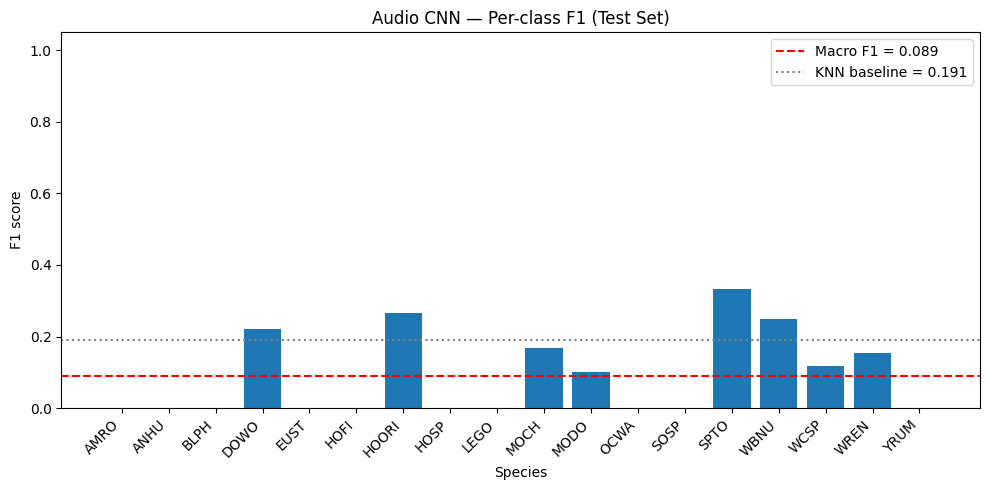

Saved: audio_cnn_per_class_f1.png


In [10]:
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(species_names, per_class_f1)
ax.axhline(cnn_macro_f1, color="red",  linestyle="--", label=f"Macro F1 = {cnn_macro_f1:.3f}")
ax.axhline(0.191,        color="gray", linestyle=":",  label="KNN baseline = 0.191")
ax.set_xlabel("Species")
ax.set_ylabel("F1 score")
ax.set_title("Audio CNN — Per-class F1 (Test Set)")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "audio_cnn_per_class_f1.png", dpi=150)
plt.show()
print("Saved: audio_cnn_per_class_f1.png")

## 9. CNN — Append to experiments.csv

In [11]:
def append_if_new(experiments_path, new_row_dict):
    """
    Append a result row to experiments.csv only if an identical
    phase + modality + model combination does not already exist.
    Prevents duplicate rows from reruns.
    """
    new_row = pd.DataFrame([new_row_dict])
    if experiments_path.exists():
        existing = pd.read_csv(experiments_path)
        already_exists = (
            (existing["model"]    == new_row_dict["model"]) &
            (existing["phase"].astype(str) == str(new_row_dict["phase"])) &
            (existing["modality"] == new_row_dict["modality"])
        ).any()
        if already_exists:
            print(f"experiments.csv — '{new_row_dict['model']}' already recorded, skipping.")
            return
        pd.concat([existing, new_row], ignore_index=True).to_csv(experiments_path, index=False)
    else:
        new_row.to_csv(experiments_path, index=False)
    print(f"experiments.csv — added: {new_row_dict['model']}")


append_if_new(experiments_path, {
    "phase":       4,
    "notebook":    "audio_birdnet.ipynb",
    "modality":    "audio",
    "model":       "CNN (mel spectrogram)",
    "n_species":   n_classes,
    "n_test":      len(audio_test),
    "accuracy":    round(float(cnn_accuracy), 3),
    "macro_f1":    round(float(cnn_macro_f1), 3),
    "weighted_f1": round(float(cnn_weighted_f1), 3),
    "notes":       f"_build_audio_cnn, {EPOCHS} epochs, weighted CE loss, Adam lr=1e-3. Underperforms KNN — insufficient data for CNN from scratch.",
})

experiments.csv — 'CNN (mel spectrogram)' already recorded, skipping.


## 10. BirdNET pretrained — inference on test set

BirdNET is a pretrained model trained on ~6,000 species from Xeno-canto and
Macaulay Library. We run it directly on our test MP3 files with no training.
Detections are matched to our 18 SD species by scientific name from species.yaml.

In [12]:
import os
import yaml
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer

# Build scientific_name -> species_code lookup from species.yaml
with open(REPO_ROOT / "configs" / "species.yaml") as f:
    species_cfg = yaml.safe_load(f)
sci_to_code = {s["scientific_name"]: s["code"] for s in species_cfg["species"]}

print("Loading BirdNET analyzer...")
analyzer = Analyzer()
print("BirdNET loaded.")

birdnet_preds = []
birdnet_true  = []
birdnet_confs = []

for _, row in audio_test.iterrows():
    file_path = row["file_path"]
    true_code = row["species_code"]

    try:
        recording = Recording(analyzer, file_path, min_conf=0.1)
        recording.analyze()
        detections = recording.detections
        if detections:
            top       = max(detections, key=lambda d: d["confidence"])
            pred_code = sci_to_code.get(top["scientific_name"], "UNKNOWN")
            conf      = top["confidence"]
        else:
            pred_code, conf = "UNKNOWN", 0.0
    except Exception as e:
        print(f"Warning: {file_path} failed: {e}")
        pred_code, conf = "UNKNOWN", 0.0

    birdnet_preds.append(pred_code)
    birdnet_true.append(true_code)
    birdnet_confs.append(conf)

print(f"Inference complete: {len(birdnet_preds)} files")
print(f"UNKNOWN predictions: {birdnet_preds.count('UNKNOWN')} / {len(birdnet_preds)}")

Loading BirdNET analyzer...
Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.
BirdNET loaded.
read_audio_data


C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


read_audio_data: complete, read  13 chunks.
analyze_recording AMRO_67401.mp3
read_audio_data
read_audio_data: complete, read  5 chunks.
analyze_recording AMRO_1089129.mp3
read_audio_data
read_audio_data: complete, read  66 chunks.
analyze_recording AMRO_138063.mp3
read_audio_data
read_audio_data: complete, read  20 chunks.
analyze_recording AMRO_165289.mp3
read_audio_data
read_audio_data: complete, read  39 chunks.
analyze_recording AMRO_165296.mp3
read_audio_data
read_audio_data: complete, read  94 chunks.
analyze_recording AMRO_165308.mp3
read_audio_data
read_audio_data: complete, read  25 chunks.
analyze_recording AMRO_825257.mp3
read_audio_data
read_audio_data: complete, read  82 chunks.
analyze_recording AMRO_1045448.mp3
read_audio_data
read_audio_data: complete, read  69 chunks.
analyze_recording AMRO_132864.mp3
read_audio_data
read_audio_data: complete, read  138 chunks.
analyze_recording AMRO_574475.mp3
read_audio_data
read_audio_data: complete, read  13 chunks.
analyze_recordi

## 11. BirdNET — Evaluation

In [13]:
known_mask    = [p != "UNKNOWN" for p in birdnet_preds]
bn_preds_full = [p if p != "UNKNOWN" else "__UNKNOWN__" for p in birdnet_preds]

bn_macro_f1    = f1_score(birdnet_true, bn_preds_full, average="macro",    zero_division=0)
bn_weighted_f1 = f1_score(birdnet_true, bn_preds_full, average="weighted", zero_division=0)
bn_accuracy    = sum(t == p for t, p in zip(birdnet_true, birdnet_preds)) / len(birdnet_true)

print("=" * 55)
print("BirdNET Pretrained — Test Set Results")
print("=" * 55)
print(f"Test accuracy : {bn_accuracy:.3f}  (CNN: {cnn_accuracy:.3f}, KNN: 0.302)")
print(f"Macro F1      : {bn_macro_f1:.3f}  (CNN: {cnn_macro_f1:.3f}, KNN: 0.191)  {'BEAT' if bn_macro_f1 > 0.191 else 'below baseline'}")
print(f"Weighted F1   : {bn_weighted_f1:.3f}  (CNN: {cnn_weighted_f1:.3f}, KNN: 0.293)")
print(f"Coverage      : {sum(known_mask)}/{len(birdnet_preds)} files got a known-species detection")

BirdNET Pretrained — Test Set Results
Test accuracy : 0.744  (CNN: 0.116, KNN: 0.302)
Macro F1      : 0.776  (CNN: 0.089, KNN: 0.191)  BEAT
Weighted F1   : 0.823  (CNN: 0.093, KNN: 0.293)
Coverage      : 66/86 files got a known-species detection


## 12. BirdNET — Confusion matrix and per-class F1

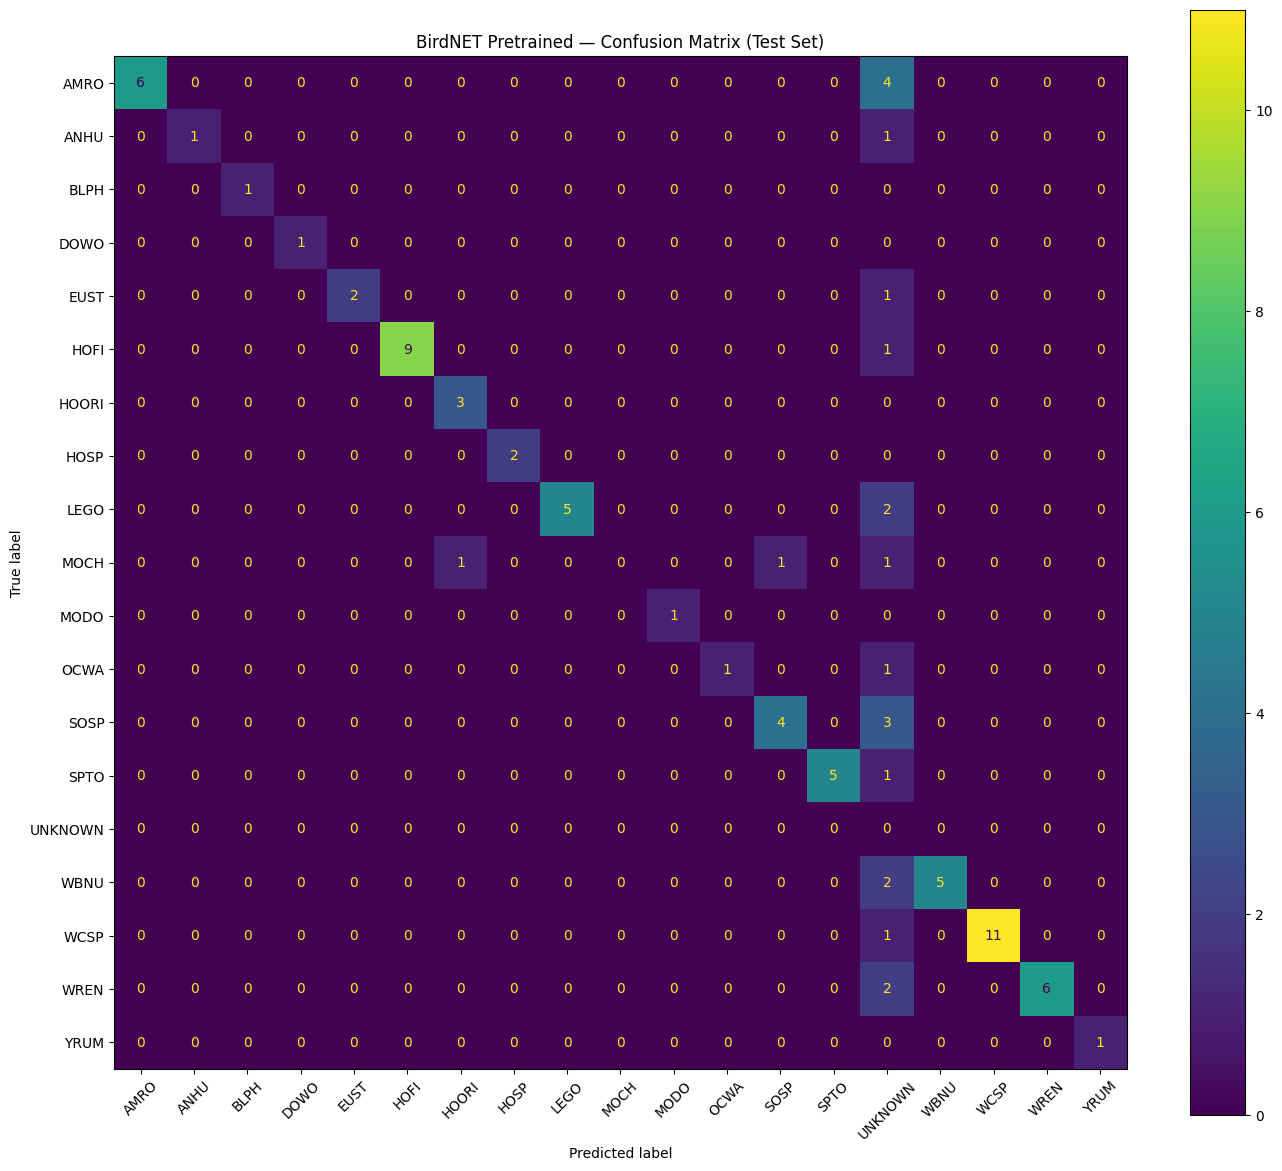

Saved: audio_birdnet_confusion_matrix.png


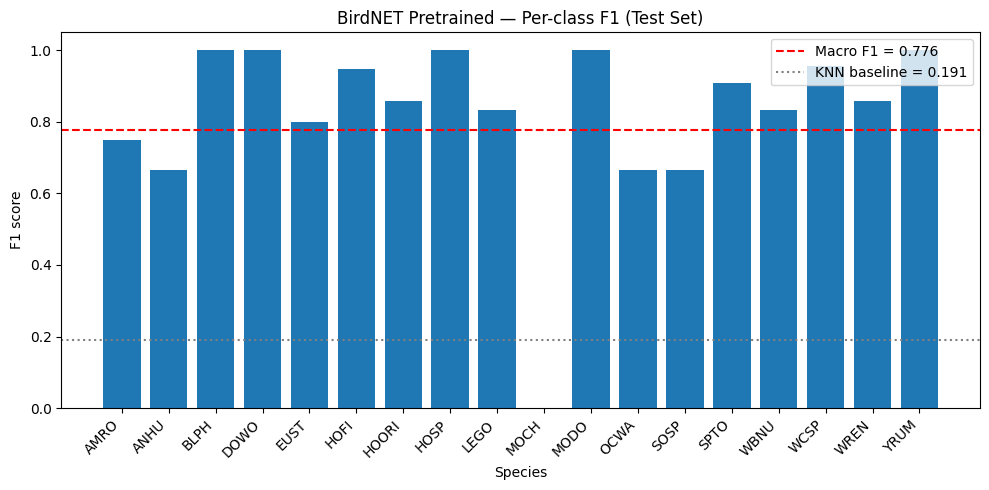

Saved: audio_birdnet_per_class_f1.png


In [14]:
bn_preds_display = [p if p != "__UNKNOWN__" else "UNKNOWN" for p in bn_preds_full]
all_labels_set   = sorted(set(birdnet_true) | set(bn_preds_display))

cm_bn = confusion_matrix(birdnet_true, bn_preds_display, labels=all_labels_set)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bn, display_labels=all_labels_set)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title("BirdNET Pretrained — Confusion Matrix (Test Set)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "audio_birdnet_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: audio_birdnet_confusion_matrix.png")

test_species    = sorted(set(birdnet_true))
per_class_f1_bn = f1_score(
    birdnet_true, bn_preds_display,
    labels=test_species,
    average=None,
    zero_division=0,
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(test_species, per_class_f1_bn)
ax.axhline(bn_macro_f1, color="red",  linestyle="--", label=f"Macro F1 = {bn_macro_f1:.3f}")
ax.axhline(0.191,       color="gray", linestyle=":",  label="KNN baseline = 0.191")
ax.set_xlabel("Species")
ax.set_ylabel("F1 score")
ax.set_title("BirdNET Pretrained — Per-class F1 (Test Set)")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "audio_birdnet_per_class_f1.png", dpi=150)
plt.show()
print("Saved: audio_birdnet_per_class_f1.png")

## 13. BirdNET — Append to experiments.csv

In [15]:
append_if_new(experiments_path, {
    "phase":       4,
    "notebook":    "audio_birdnet.ipynb",
    "modality":    "audio",
    "model":       "BirdNET pretrained (birdnetlib 0.9.0)",
    "n_species":   n_classes,
    "n_test":      len(audio_test),
    "accuracy":    round(float(bn_accuracy), 3),
    "macro_f1":    round(float(bn_macro_f1), 3),
    "weighted_f1": round(float(bn_weighted_f1), 3),
    "notes":       f"BirdNET global model, no fine-tuning, min_conf=0.1, matched on scientific_name. {sum(known_mask)}/{len(birdnet_preds)} files detected.",
})

experiments.csv — 'BirdNET pretrained (birdnetlib 0.9.0)' already recorded, skipping.
